NAME: ALOK KUMAR MAVI, SEC: B, ROLL.NO.05

# LAB SHEET - 10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.datasets import mnist

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


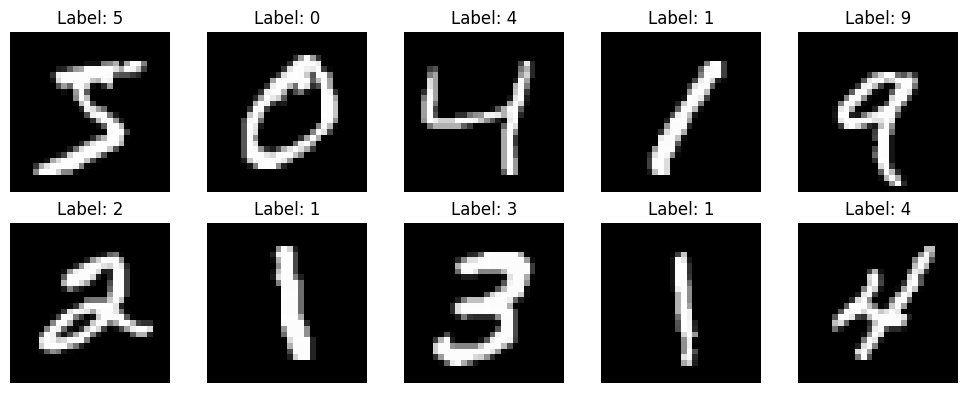

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)


In [6]:
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train_final = x_train[:-10000]
y_train_final = y_train[:-10000]

print("Training set  :", x_train_final.shape)
print("Validation set:", x_val.shape)
print("Testing set   :", x_test.shape)

Training set  : (50000, 28, 28, 1)
Validation set: (10000, 28, 28, 1)
Testing set   : (10000, 28, 28, 1)


In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [9]:
history = model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9457 - loss: 0.1788 - val_accuracy: 0.9834 - val_loss: 0.0607
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9839 - loss: 0.0529 - val_accuracy: 0.9859 - val_loss: 0.0457
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9872 - val_loss: 0.0428
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9913 - loss: 0.0267 - val_accuracy: 0.9870 - val_loss: 0.0458
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9936 - loss: 0.0208 - val_accuracy: 0.9903 - val_loss: 0.0338


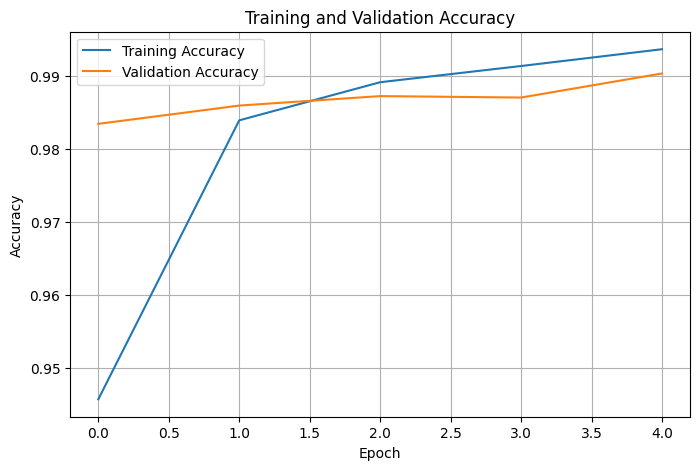

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

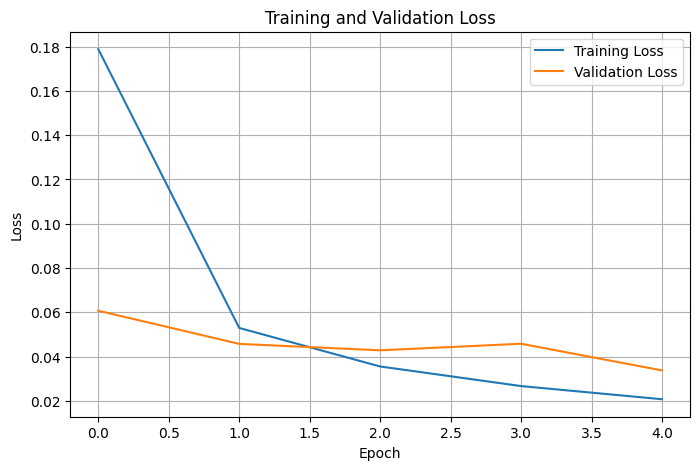

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9910 - loss: 0.0282
Test Loss     : 0.028171325102448463
Test Accuracy : 0.9909999966621399


In [13]:
y_probability = model.predict(x_test)

y_pred = np.argmax(y_probability, axis=1)

print("Predictions generated successfully.")
print("First 20 predicted labels:", y_pred[:20])
print("First 20 actual labels   :", y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated successfully.
First 20 predicted labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 actual labels   : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Classification Metrics")
print("-" * 35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Classification Metrics
-----------------------------------
Accuracy  : 0.9910
Precision : 0.9910
Recall    : 0.9910
F1-Score  : 0.9910


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 974    0    0    0    1    0    1    3    0    1]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   2    0 1020    0    2    0    0    6    1    1]
 [   0    0    1 1001    0    3    0    1    3    1]
 [   0    0    0    0  976    0    0    0    0    6]
 [   1    0    0    6    0  882    1    1    0    1]
 [   5    2    0    0    3    6  941    0    1    0]
 [   0    2    1    0    0    0    0 1022    0    3]
 [   3    0    1    0    0    1    2    2  960    5]
 [   0    2    0    0    3    3    0    2    0  999]]


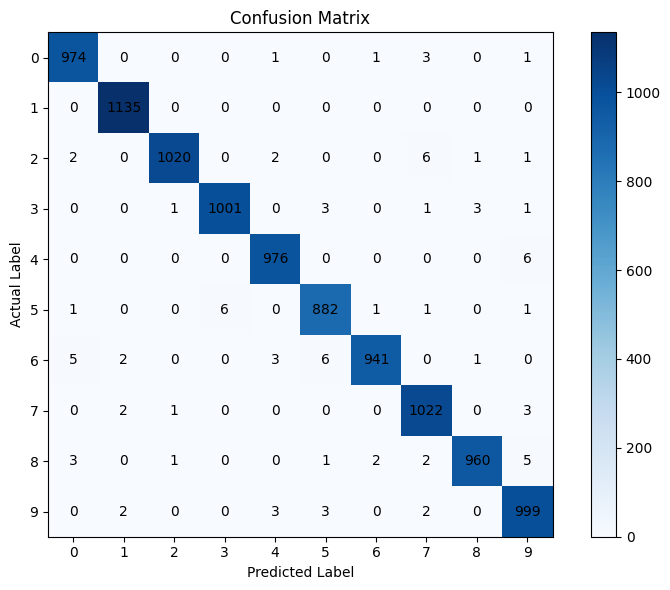

In [16]:
plt.figure(figsize=(8, 6))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

plt.xticks(np.arange(10), np.arange(10))
plt.yticks(np.arange(10), np.arange(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



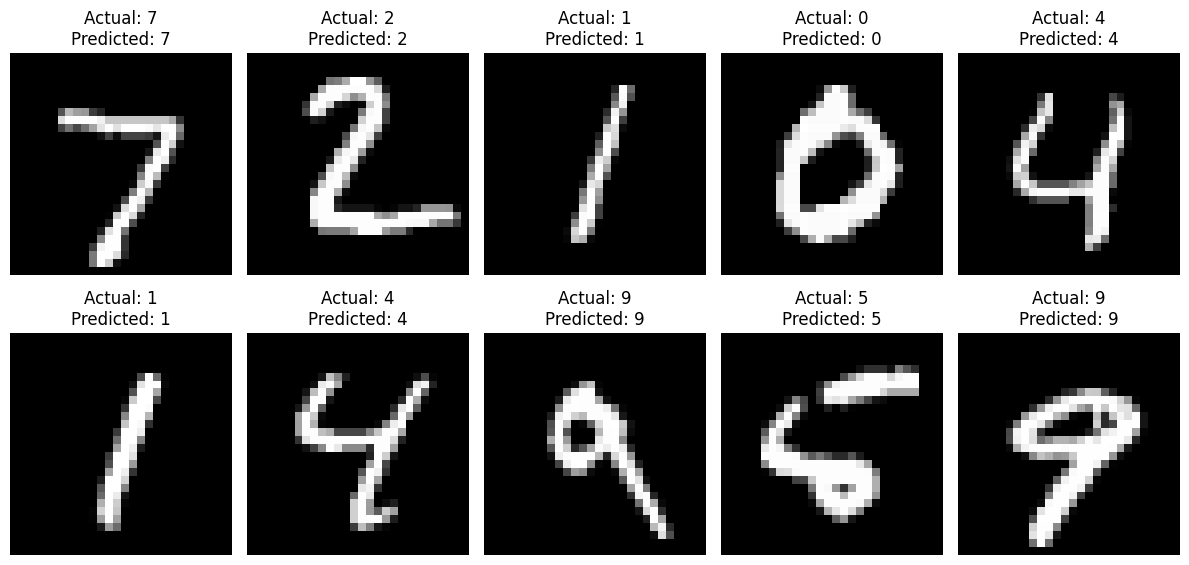

In [18]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
misclassified = np.where(y_pred != y_test)[0]

print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 90


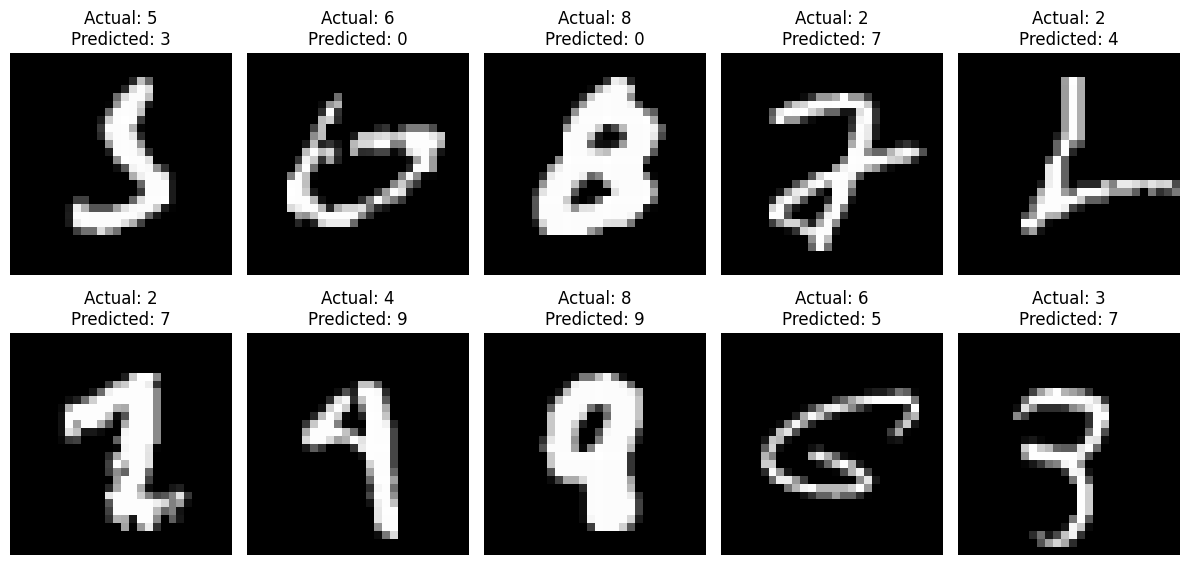

In [20]:
plt.figure(figsize=(12, 6))

for i, index in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[index].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
model.save("/content/mnist_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [22]:
import os

if os.path.exists("/content/mnist_cnn_model.keras"):
    print("Saved file: mnist_cnn_model.keras")

Saved file: mnist_cnn_model.keras


In [23]:
print("=" * 50)
print("CNN IMAGE CLASSIFICATION SUMMARY")
print("=" * 50)

print("Dataset             : MNIST")
print("Model               : Convolutional Neural Network")
print("Training Images     :", len(x_train_final))
print("Validation Images   :", len(x_val))
print("Testing Images      :", len(x_test))
print("Number of Classes   : 10")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")
print("Misclassified       :", len(misclassified))
print("=" * 50)

CNN IMAGE CLASSIFICATION SUMMARY
Dataset             : MNIST
Model               : Convolutional Neural Network
Training Images     : 50000
Validation Images   : 10000
Testing Images      : 10000
Number of Classes   : 10
Test Accuracy       : 0.9910
Precision           : 0.9910
Recall              : 0.9910
F1-Score            : 0.9910
Misclassified       : 90


# Questions and Answers

##### Ques 1- What is image classification? How does it differ from object detection and image segmentation?

**Ans-** Image classification is the process of assigning a class or category to an entire image. For example, a CNN can classify a handwritten image as the digit 5.

The main differences are:

| Task                 | Purpose                                             | Output                        |
| -------------------- | --------------------------------------------------- | ----------------------------- |
| Image Classification | Identifies the category of the image                | Class label                   |
| Object Detection     | Identifies and locates objects in an image          | Class labels + bounding boxes |
| Image Segmentation   | Divides an image into meaningful regions or objects | Pixel-level regions or masks  |

Thus, classification tells us **what the image contains**, object detection tells us **what objects are present and where they are**, and segmentation identifies **the exact regions or pixels belonging to those objects**.

---

##### Ques 2- Explain the architecture and working principle of a Convolutional Neural Network (CNN).

**Ans-** A Convolutional Neural Network (CNN) is a deep learning model designed mainly for processing image data. It automatically learns hierarchical features from images, reducing the need for manually designed feature extraction.

A typical CNN consists of the following stages:

1. **Input Layer** – Receives the image.
2. **Convolutional Layers** – Extract important features such as edges, shapes, and textures.
3. **Activation Functions** – Introduce non-linearity into the network.
4. **Pooling Layers** – Reduce the spatial dimensions of feature maps.
5. **Flatten Layer** – Converts the extracted feature maps into a one-dimensional vector.
6. **Fully Connected Layers** – Use the extracted features for classification.
7. **Output Layer** – Produces the final class probabilities.

During training, the CNN learns suitable weights by comparing its predictions with the actual labels and updating the weights using backpropagation.

---

##### Ques 3- What is the role of Convolutional Layers, Pooling Layers, and Fully Connected Layers in a CNN?

**Ans-**

**Convolutional Layers:**
They apply filters to the input image to extract useful features such as edges, corners, textures, and shapes. Deeper convolutional layers can learn more complex features.

**Pooling Layers:**
They reduce the spatial size of feature maps while retaining important information. This decreases the computational requirements and can help the network become less sensitive to small changes in the position of features.

**Fully Connected Layers:**
They combine the features extracted by the earlier layers and use them to perform the final classification. The output layer then produces the probability of each class.

Together, these layers allow a CNN to learn image features and classify images automatically.

---

##### Ques 4- Why is image normalization performed before training a deep learning model?

**Ans-** Image normalization is performed to scale pixel values into a smaller and consistent numerical range. For example, pixel values ranging from 0 to 255 can be converted to values between 0 and 1.

Normalization helps make the training process more stable and efficient. It allows the optimization algorithm to work with appropriately scaled input values and can help the model converge faster during training.

The experiment includes normalization as an important preprocessing step before CNN training.

---

##### Ques 5- Explain the purpose of activation functions such as ReLU and Softmax in CNNs.

**Ans-**

**ReLU (Rectified Linear Unit):**
ReLU is commonly used in hidden layers of CNNs. It converts negative values to zero while keeping positive values unchanged.

The function is:

**ReLU(x) = max(0, x)**

It introduces non-linearity into the network and allows the CNN to learn complex patterns.

**Softmax:**
Softmax is generally used in the final layer for multi-class classification. It converts the output values into probabilities whose total is equal to 1. The class with the highest probability is generally selected as the predicted class.

Thus, ReLU helps the network learn complex features, while Softmax helps produce class probabilities at the output.

---

##### Ques 6- What is a Confusion Matrix? How is it used to evaluate classification performance?

**Ans-** A Confusion Matrix is a table used to compare the actual class labels with the predicted class labels of a classification model.

For a multi-class classification problem such as MNIST, each row represents an actual class and each column represents a predicted class.

For example:

* A value on the main diagonal represents a correctly classified sample.
* A value outside the diagonal represents a misclassified sample.

The confusion matrix helps identify which classes are being classified correctly and which classes are frequently confused with one another. It is one of the evaluation methods required in this experiment.

---

##### Ques 7- Differentiate between Accuracy, Precision, Recall, and F1-Score with suitable examples.

**Ans-** These metrics measure different aspects of classification performance.

**Accuracy:**
It is the proportion of total predictions that are correct.

**Accuracy = (TP + TN) / (TP + TN + FP + FN)**

**Precision:**
It measures how many of the samples predicted as positive are actually positive.

**Precision = TP / (TP + FP)**

**Recall:**
It measures how many of the actual positive samples are correctly identified.

**Recall = TP / (TP + FN)**

**F1-Score:**
It is the harmonic mean of precision and recall.

**F1-Score = 2 × (Precision × Recall) / (Precision + Recall)**

For example, suppose a classifier predicts 100 images as a particular digit, but only 90 of them are actually that digit. Its precision for that class would be 90%. If there are 100 actual images of that digit and the model correctly identifies 90 of them, its recall would also be 90%.

The experiment requires Accuracy, Precision, Recall, and F1-Score for evaluating the trained CNN.

---

##### Ques 8- Compare traditional feature-based image classification methods (e.g., SIFT/HOG + SVM) with CNN-based classification.

**Ans-**

| Feature                   | Traditional Methods (SIFT/HOG + SVM)          | CNN-Based Classification                |
| ------------------------- | --------------------------------------------- | --------------------------------------- |
| Feature Extraction        | Handcrafted features such as SIFT or HOG      | Features learned automatically          |
| Classifier                | Usually SVM or another traditional classifier | Neural network                          |
| Feature Learning          | Requires manual feature design                | Learned during training                 |
| Complex Images            | May require careful feature engineering       | Can learn complex hierarchical features |
| Data Requirement          | Often works with smaller datasets             | Usually benefits from larger datasets   |
| Computational Requirement | Generally lower                               | Generally higher                        |

CNNs automatically learn hierarchical image features, eliminating the need for handcrafted feature extraction techniques.

---

##### Ques 9- Mention five real-world applications of CNN-based image classification.

**Ans-** Five important applications of CNN-based image classification are:

1. **Handwritten digit recognition** — recognizing digits written by hand.
2. **Facial recognition** — identifying or classifying faces.
3. **Biometric authentication** — verifying a person's identity using biometric information.
4. **Medical diagnosis** — classifying medical images or identifying disease-related patterns.
5. **Intelligent document processing** — recognizing and classifying information in documents.

These applications are specifically identified as important applications of CNN-based image classification in the experiment.

---

##### Ques 10- How can techniques such as Data Augmentation, Transfer Learning, and Hyperparameter Tuning improve the performance of deep learning-based image classification models?

**Ans-**

**Data Augmentation:**
Data augmentation creates additional training examples by applying transformations such as rotation, flipping, cropping, or scaling. This increases the variety of training data and can reduce overfitting.

**Transfer Learning:**
Transfer learning uses a model that has already learned useful features from a large dataset and adapts it to a new classification task. This can reduce training requirements and improve performance when the available dataset is limited.

**Hyperparameter Tuning:**
Hyperparameter tuning involves selecting suitable values for parameters such as learning rate, batch size, number of layers, number of filters, and training epochs. Proper values can improve both the learning process and final classification performance.

Together, these techniques can improve generalization, training efficiency, and classification accuracy. The experiment also requires configuring parameters such as optimizer, learning rate, batch size, and number of epochs.
